In [1]:
# Test the base classes
import sys
sys.path.append('.')  # Add current directory to path

from cascaded_tn.core.base import LayerConfig, CascadableOperator, DebugInfo

# Test 1: LayerConfig validation
print("Test 1: LayerConfig")
print("-" * 40)

# Valid configuration
config1 = LayerConfig(input_dim=56, output_dim=32, bond_dim=16)
print(f"✅ Valid config: {config1}")

# Configuration with warning (expansion)
config2 = LayerConfig(input_dim=32, output_dim=56, bond_dim=16)
print(f"✅ Expansion config created (see warning above)")

# Test invalid configurations
try:
    bad_config = LayerConfig(input_dim=0, output_dim=32, bond_dim=16)
except ValueError as e:
    print(f"✅ Caught expected error: {e}")

print("\n" + "="*60 + "\n")

# Test 2: Create a mock cascadable operator
print("Test 2: Mock Cascadable Operator")
print("-" * 40)

class MockOperator(CascadableOperator):
    def __init__(self, config: LayerConfig, **kwargs):
        super().__init__(**kwargs)
        self.config = config
    
    def apply(self, input_tn):
        # Mock implementation
        print(f"   Applying {self}")
        return input_tn
    
    def get_config(self):
        return self.config

# Create operators with different debug levels
op1 = MockOperator(LayerConfig(56, 32, 16), debug=True, debug_level=1)
op2 = MockOperator(LayerConfig(32, 16, 12), debug=True, debug_level=1)
op3 = MockOperator(LayerConfig(16, 8, 8), debug=True, debug_level=1)

print(f"Operator 1: {op1}")
print(f"Operator 2: {op2}")
print(f"Operator 3: {op3}")

print("\n" + "="*60 + "\n")

# Test 3: Validation
print("Test 3: Operator Validation")
print("-" * 40)

# Valid connection
valid, msg = op1.validates_with(op2)
print(f"op1 → op2: {'✅ Valid' if valid else '❌ Invalid'} - {msg}")

# Invalid connection (dimension mismatch)
bad_op = MockOperator(LayerConfig(64, 32, 16))
valid, msg = bad_op.validates_with(op2)
print(f"bad_op → op2: {'✅ Valid' if valid else '❌ Invalid'} - {msg}")

# Cyclic mismatch (warning)
cyclic_op = MockOperator(LayerConfig(32, 16, 12, cyclic=True))
valid, msg = op1.validates_with(cyclic_op)
print(f"op1 → cyclic_op: {'✅ Valid' if valid else '❌ Invalid'} (see warning above)")

print("\n" + "="*60 + "\n")

# Test 4: Debug Info
print("Test 4: Debug Info Collection")
print("-" * 40)

debug_info = DebugInfo()

# Simulate layer execution
import time
for i, op in enumerate([op1, op2, op3]):
    start = time.time()
    time.sleep(0.01)  # Simulate work
    elapsed = time.time() - start
    debug_info.add_layer_info(i, elapsed, 1.234 + i*0.1, f"(100, {op.output_dim})")

# Add some warnings
debug_info.warnings.append("Test warning 1")
debug_info.warnings.append("Test warning 2")

# Print summary
debug_info.summary()

print("\n✅ All base class tests passed!")

Test 1: LayerConfig
----------------------------------------
✅ Valid config: LayerConfig(input_dim=56, output_dim=32, bond_dim=16, spacing=None, cyclic=False, phys_dim=(2, 2), add_identity=False)
[WARNING] Expansion layer detected: 32 → 56
          This will require special handling
✅ Expansion config created (see warning above)
✅ Caught expected error: Dimensions must be positive: input=0, output=32


Test 2: Mock Cascadable Operator
----------------------------------------
Operator 1: MockOperator(56→32, χ=16)
Operator 2: MockOperator(32→16, χ=12)
Operator 3: MockOperator(16→8, χ=8)


Test 3: Operator Validation
----------------------------------------
op1 → op2: ✅ Valid - 
bad_op → op2: ✅ Valid - 
[WARNING] Boundary condition mismatch: open → cyclic
op1 → cyclic_op: ✅ Valid (see warning above)


Test 4: Debug Info Collection
----------------------------------------
[DEBUG] Layer 0: 0.010s, norm=1.234000, shape=(100, 32)
[DEBUG] Layer 1: 0.010s, norm=1.334000, shape=(100, 16)
[DEBUG

In [2]:
# Enhanced test for dimension calculator with cyclic support
from cascaded_tn.builders.dimension_calculator import DimensionCalculator, SpacingResult
from cascaded_tn.core.base import LayerConfig

print("="*60)
print("ENHANCED DIMENSION CALCULATOR TESTS")
print("="*60)

calc = DimensionCalculator(debug=True)

# Test 1: Original autoencoder - now with cyclic warnings
print("\nTest 1: Autoencoder 56→32→16→3 with CYCLIC=TRUE")
print("-" * 40)

layer_dims = [56, 32, 16, 3]
cyclic_spacings = calc.calculate_cascade_spacings(layer_dims, cyclic=True)

print("\nResults with warnings handled:")
for i, result in enumerate(cyclic_spacings):
    print(f"  Layer {i}: {result}")

# Test 2: Get suggested cyclic-compatible dimensions
print("\n\nTest 2: Suggest Cyclic-Compatible Dimensions")
print("-" * 40)

print("\nFor input=56, 3 layers, target≈3:")
suggested = calc.suggest_cyclic_compatible_dims(56, 3, target_output=3)
print(f"  Suggested: {' → '.join(map(str, suggested))}")

print("\nFor input=56, 3 layers, no target:")
suggested_auto = calc.suggest_cyclic_compatible_dims(56, 3)
print(f"  Suggested: {' → '.join(map(str, suggested_auto))}")

print("\nFor input=100, 4 layers, target=5:")
suggested_100 = calc.suggest_cyclic_compatible_dims(100, 4, target_output=5)
print(f"  Suggested: {' → '.join(map(str, suggested_100))}")

# Test 3: Try the suggested dimensions
print("\n\nTest 3: Using Suggested Cyclic Dimensions")
print("-" * 40)

# Use the suggested dimensions for 56
good_cyclic_dims = calc.suggest_cyclic_compatible_dims(56, 3, target_output=4)
print(f"\nTrying: {' → '.join(map(str, good_cyclic_dims))}")

good_spacings = calc.calculate_cascade_spacings(good_cyclic_dims, cyclic=True)
print("\nSpacing results (should all be efficient):")
for i, result in enumerate(good_spacings):
    print(f"  Layer {i}: {result}")

# Test 4: Check compatibility function directly
print("\n\nTest 4: Direct Compatibility Checking")
print("-" * 40)

test_cases = [
    [64, 32, 16, 8, 4, 2, 1],  # Perfect powers of 2
    [60, 30, 15, 5],            # Nice divisors
    [56, 32, 16, 3],            # Original (problematic)
    [100, 50, 25, 10, 5]        # Another good sequence
]

for dims in test_cases:
    issues = calc.check_cyclic_compatibility(dims)
    status = "✅ Compatible" if not issues else f"❌ {len(issues)} issues"
    print(f"{' → '.join(map(str, dims))}: {status}")
    if issues:
        for issue in issues[:1]:  # Just show first issue to save space
            print(f"    {issue}")

# Test 5: Explore divisor structure
print("\n\nTest 5: Understanding Divisor Constraints")
print("-" * 40)

for test_dim in [56, 60, 64, 100]:
    divisors = calc._get_divisors(test_dim)
    possible_outputs = [test_dim // d for d in divisors if d > 1]
    print(f"\nDim {test_dim} can compress to: {possible_outputs[:10]}...")

# Test 6: Real autoencoder with proper cyclic dimensions
print("\n\nTest 6: Complete Cyclic Autoencoder Setup")
print("-" * 40)

# Let's design a proper cyclic autoencoder
input_size = 56
target_bottleneck = 7  # Much more realistic for cyclic

# Get encoder dimensions
encoder_dims = calc.suggest_cyclic_compatible_dims(input_size, 2, target_bottleneck)
# Mirror for decoder
full_dims = encoder_dims + encoder_dims[-2::-1]  # [56, 14, 7, 14, 56]

print(f"Full autoencoder architecture: {' → '.join(map(str, full_dims))}")

# Calculate spacings
spacings = calc.calculate_cascade_spacings(full_dims, cyclic=True)
print("\nAll spacings:")
for i, result in enumerate(spacings):
    print(f"  Layer {i}: {result}")

# Verify it's actually cyclic-compatible
issues = calc.check_cyclic_compatibility(full_dims)
print(f"\nValidation: {'✅ Fully cyclic-compatible!' if not issues else '❌ Issues found'}")

print("\n✅ Enhanced cyclic tests complete!")

ENHANCED DIMENSION CALCULATOR TESTS

Test 1: Autoencoder 56→32→16→3 with CYCLIC=TRUE
----------------------------------------

⚠️  CYCLIC COMPATIBILITY WARNING
  ❌ Layer 0: 56→32 impossible with cyclic. Valid outputs: [56, 28, 14, 8, 7]...
  ❌ Layer 2: 16→3 impossible with cyclic. Valid outputs: [16, 8, 4, 2, 1]...
[WARNING] Target 3 not achievable, using 4

  💡 Suggested cyclic-compatible dimensions:
     56 → 28 → 8 → 4


[DIM_CALC] Layer 0: 56 → 32
[DIM_CALC] SpacingResult(spacing=2, outputs=28/32, eff=87.5%, method='uniform_approx')

[DIM_CALC] Layer 1: 32 → 16
[DIM_CALC] SpacingResult(spacing=2, outputs=16/16, eff=100.0%, method='uniform')

[DIM_CALC] Layer 2: 16 → 3
[WARNING] Cyclic: 16→3 not exactly achievable.
          Possible outputs: [16, 8, 4, 2, 1]
          Using 4 (spacing=4)
[WARNING] Cyclic: 16→3 not exactly achievable.
          Possible outputs: [16, 8, 4, 2, 1]
          Using 4 (spacing=4)
[WARNING] Cyclic: 16→3 not exactly achievable.
          Possible outputs: 

In [3]:
# Test the cascadable SMPO operator
import jax
import jax.numpy as jnp
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
from tn4ml.models.smpo import SMPO_initialize
from jax.nn.initializers import normal

from cascaded_tn.core.operator import CascadableSMPO, ExpansionSMPO
from cascaded_tn.core.base import LayerConfig
from cascaded_tn.builders.dimension_calculator import DimensionCalculator

print("="*60)
print("CASCADABLE SMPO TESTS")
print("="*60)

# Test 1: Create from existing SMPO
print("\nTest 1: Wrap Existing SMPO")
print("-" * 40)

# Create a regular tn4ml SMPO
key = jax.random.PRNGKey(42)
existing_smpo = SMPO_initialize(
    L=56,
    initializer=normal(stddev=0.1),
    key=key,
    spacing=2,
    bond_dim=8,
    phys_dim=(2, 2),
    cyclic=False,
    boundary='obc'
)

# Wrap it
cascadable = CascadableSMPO(smpo=existing_smpo, debug=True, debug_level=1)
print(f"✅ Created: {cascadable}")
print(f"   Config: {cascadable.get_config()}")

# Test 2: Create from LayerConfig
print("\n\nTest 2: Create from Configuration")
print("-" * 40)

# Use our dimension calculator to get proper spacing
calc = DimensionCalculator(debug=False)
spacing_result = calc.calculate_optimal_spacing(32, 16, cyclic=False)

config = LayerConfig(
    input_dim=32,
    output_dim=16,
    bond_dim=12,
    spacing=spacing_result.spacing,
    cyclic=False
)

cascadable2 = CascadableSMPO(
    config=config,
    key=jax.random.split(key)[0],
    debug=True
)
print(f"✅ Created: {cascadable2}")

# Test 3: Test debug information
print("\n\nTest 3: Debug Information")
print("-" * 40)

debug_info = cascadable.get_debug_info()
print("Debug info for first operator:")
for k, v in debug_info.items():
    print(f"  {k}: {v}")

# Test 4: Test validation between operators
print("\n\nTest 4: Operator Validation")
print("-" * 40)

# These should connect
valid, msg = cascadable.validates_with(cascadable2)
print(f"56→28 connects to 32→16: {'✅' if valid else '❌'} {msg}")

# Create matching operators
config_28_to_14 = LayerConfig(28, 14, 10, spacing=2)
cascadable3 = CascadableSMPO(config=config_28_to_14, key=jax.random.split(key)[1])

valid, msg = cascadable.validates_with(cascadable3)
print(f"56→28 connects to 28→14: {'✅' if valid else '❌'} {msg}")

# Test 5: Cyclic SMPO
print("\n\nTest 5: Cyclic SMPO Creation")
print("-" * 40)

# Get cyclic-compatible dimensions
cyclic_dims = calc.suggest_cyclic_compatible_dims(56, 2, target_output=7)
print(f"Cyclic architecture: {' → '.join(map(str, cyclic_dims))}")

# Create cyclic operators
cyclic_configs = []
keys = jax.random.split(key, len(cyclic_dims)-1)

for i in range(len(cyclic_dims)-1):
    spacing_res = calc.calculate_optimal_spacing(
        cyclic_dims[i], cyclic_dims[i+1], cyclic=True
    )
    
    config = LayerConfig(
        input_dim=cyclic_dims[i],
        output_dim=cyclic_dims[i+1],
        bond_dim=8,
        spacing=spacing_res.spacing,
        cyclic=True
    )
    
    op = CascadableSMPO(config=config, key=keys[i], debug=False)
    print(f"  Layer {i}: {op}")
    cyclic_configs.append(op)

# Test 6: Mock MPS application (simplified test)
print("\n\nTest 6: Application Test (Mock)")
print("-" * 40)

# Create a mock MPS-like object
class MockMPS:
    def __init__(self, L, cyclic=False):
        self.L = L
        self.cyclic = cyclic
        self.tensors = [jnp.ones((2, 2, 2)) for _ in range(L)]
    
    def norm(self):
        return 1.0
    
    def bond_size(self, i, j):
        return 2

# Test application with debug
print("Testing SMPO application with debugging:")
cascadable_debug = CascadableSMPO(
    config=LayerConfig(10, 5, 4, spacing=2),
    key=jax.random.split(key)[2],
    debug=True,
    debug_level=2
)

mock_mps = MockMPS(10, cyclic=False)

# Note: This will fail since MockMPS isn't a real MPS, but we'll see debug output
try:
    output = cascadable_debug.apply(mock_mps)
except Exception as e:
    print(f"Expected error (mock MPS): {type(e).__name__}")

# Test 7: Expansion operator placeholder
print("\n\nTest 7: Expansion Operator (Placeholder)")
print("-" * 40)

try:
    expansion = ExpansionSMPO(LayerConfig(8, 16, 10))
except ValueError as e:
    print(f"✅ Caught expected error: {e}")

expansion = ExpansionSMPO(LayerConfig(8, 32, 10), debug=True)
print(f"✅ Created placeholder: {expansion}")

# Test 8: Full cascade setup preview
print("\n\nTest 8: Preview Full Cascade Setup")
print("-" * 40)

# Design a complete autoencoder
dims = [56, 28, 14, 7]  # Cyclic-compatible
operators = []

print("Encoder layers:")
for i in range(len(dims)-1):
    spacing_res = calc.calculate_optimal_spacing(dims[i], dims[i+1], cyclic=True)
    config = LayerConfig(
        dims[i], dims[i+1], 
        bond_dim=16-i*4,  # Decreasing bond dims
        spacing=spacing_res.spacing,
        cyclic=True
    )
    op = CascadableSMPO(config=config, key=jax.random.split(key, 10)[i])
    operators.append(op)
    print(f"  {op}")

print("\nReady for cascade container implementation!")
print("✅ All operator tests complete!")

CASCADABLE SMPO TESTS

Test 1: Wrap Existing SMPO
----------------------------------------
[INIT] Created CascadableSMPO(56→28, χ=8, s=2)
✅ Created: CascadableSMPO(56→28, χ=8, s=2)
   Config: LayerConfig(input_dim=56, output_dim=28, bond_dim=8, spacing=2, cyclic=False, phys_dim=<bound method TensorNetworkGenOperator.phys_dim of SpacedMatrixProductOperator(tensors=56, indices=139, L=56, max_bond=8)>, add_identity=False)


Test 2: Create from Configuration
----------------------------------------
[CREATE] Building SMPO: L=32, spacing=2, cyclic=False
[INIT] Created CascadableSMPO(32→16, χ=12, s=2)
✅ Created: CascadableSMPO(32→16, χ=12, s=2)


Test 3: Debug Information
----------------------------------------
Debug info for first operator:
  applications: 0
  last_input_shape: None
  last_output_shape: None
  config: LayerConfig(input_dim=56, output_dim=28, bond_dim=8, spacing=2, cyclic=False, phys_dim=<bound method TensorNetworkGenOperator.phys_dim of SpacedMatrixProductOperator(tensors=5

In [2]:
# Test the TensorNetworkCascade container
import jax
import jax.numpy as jnp
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
from cascaded_tn.core.cascade import TensorNetworkCascade
from cascaded_tn.core.operator import CascadableSMPO
from cascaded_tn.core.base import LayerConfig
from cascaded_tn.builders.dimension_calculator import DimensionCalculator

print("="*60)
print("TENSOR NETWORK CASCADE TESTS")
print("="*60)

# Setup
calc = DimensionCalculator(debug=False)
key = jax.random.PRNGKey(42)

# Test 1: Create a simple cascade
print("\nTest 1: Basic Cascade Creation")
print("-" * 40)

# Create operators for 56→28→14→7
dims = [56, 28, 14, 7]
operators = []

for i in range(len(dims)-1):
    spacing_res = calc.calculate_optimal_spacing(dims[i], dims[i+1])
    config = LayerConfig(
        dims[i], dims[i+1],
        bond_dim=16-i*2,  # Decreasing: 16, 14, 12
        spacing=spacing_res.spacing
    )
    op = CascadableSMPO(
        config=config,
        key=jax.random.split(key, 10)[i],
        debug=False  # Less verbose for cascade test
    )
    operators.append(op)

# Create cascade
cascade = TensorNetworkCascade(operators, name="TestAutoencoder")
print(f"✅ Created: {cascade}")

# Test 2: Summary functionality
print("\n\nTest 2: Cascade Summary")
print("-" * 40)
cascade.summary()

# Test 3: Slice notation
print("\n\nTest 3: Slice Notation Access")
print("-" * 40)

print(f"First operator: {cascade[0]}")
print(f"Last operator: {cascade[-1]}")
print(f"First two layers: {cascade[0:2]}")
print(f"Encoder portion: {cascade.encoder}")
print(f"Decoder portion: {cascade.decoder}")

# Fixed test for dimension calculator - Test 4
print("\n\nTest 4: Validation Error Detection")
print("-" * 40)

# Method 1: Create with auto-calculated spacing (now works!)
print("Method 1: Auto-calculated spacing")
auto_op1 = CascadableSMPO(
    config=LayerConfig(56, 28, 16),  # No spacing specified
    key=jax.random.split(key)[0],
    debug=True
)
print(f"✅ Created with auto-spacing: {auto_op1}")

# Method 2: Create with pre-calculated spacing (safer)
print("\nMethod 2: Pre-calculated spacing")
spacing_res = calc.calculate_optimal_spacing(32, 16)
safe_op2 = CascadableSMPO(
    config=LayerConfig(32, 16, 12, spacing=spacing_res.spacing),
    key=jax.random.split(key)[1]
)
print(f"✅ Created with pre-calculated spacing: {safe_op2}")

# Now test the actual mismatch
print("\nTesting dimension mismatch:")
bad_ops = [
    auto_op1,  # 56→28
    safe_op2   # 32→16 (32 != 28!)
]

try:
    bad_cascade = TensorNetworkCascade(bad_ops, name="BadCascade")
except Exception as e:
    print(f"✅ Caught validation error:\n   {e}")

# Test edge case: spacing would be 1
print("\n\nTest 4b: Edge Case - Spacing=1")
print("-" * 40)

try:
    # This would require spacing=1 (all outputs)
    edge_op = CascadableSMPO(
        config=LayerConfig(32, 32, 8),  # Same input/output
        key=jax.random.split(key)[2],
        debug=True
    )
    print(f"Created: {edge_op}")
except ValueError as e:
    print(f"Expected behavior: {e}")

# Test 5: Cyclic cascade
print("\n\nTest 5: Cyclic Cascade")
print("-" * 40)

# Use cyclic-compatible dimensions
cyclic_dims = calc.suggest_cyclic_compatible_dims(56, 3, target_output=7)
print(f"Cyclic dimensions: {' → '.join(map(str, cyclic_dims))}")

cyclic_ops = []
for i in range(len(cyclic_dims)-1):
    spacing_res = calc.calculate_optimal_spacing(
        cyclic_dims[i], cyclic_dims[i+1], cyclic=True
    )
    config = LayerConfig(
        cyclic_dims[i], cyclic_dims[i+1],
        bond_dim=12,
        spacing=spacing_res.spacing,
        cyclic=True
    )
    op = CascadableSMPO(config=config, key=jax.random.split(key, 20)[i])
    cyclic_ops.append(op)

cyclic_cascade = TensorNetworkCascade(cyclic_ops, name="CyclicCascade")
cyclic_cascade.summary()

# Test 6: Layer information access
print("\n\nTest 6: Layer Information")
print("-" * 40)

for i in range(len(cascade)):
    info = cascade.get_layer_info(i)
    print(f"\nLayer {i}:")
    print(f"  Operator: {info['operator']}")
    print(f"  Dimensions: {info['input_dim']} → {info['output_dim']}")
    print(f"  Cyclic: {info['cyclic']}")

# Test 7: Mock application with timing
print("\n\nTest 7: Mock Application Test")
print("-" * 40)

# Create small cascade for testing
small_cascade = TensorNetworkCascade([
    CascadableSMPO(config=LayerConfig(10, 5, 4), key=jax.random.split(key)[0], debug=True),
    CascadableSMPO(config=LayerConfig(5, 2, 4), key=jax.random.split(key)[1], debug=True)
], name="SmallCascade", debug=True)

# Mock MPS
class SimpleMockMPS:
    def __init__(self, L):
        self.L = L
        self.data = jnp.ones(L)
    def norm(self):
        return jnp.linalg.norm(self.data)

mock_input = SimpleMockMPS(10)

# This will fail but show debug output
try:
    output = small_cascade.apply(mock_input)
except Exception as e:
    print(f"\nExpected error with mock MPS: {type(e).__name__}")

# Test 8: Architecture Analysis (encoder only for now)
print("\n\nTest 8: Architecture Analysis (Encoder Only)")
print("-" * 40)

# Create encoder-only cascade (compression only)
encoder_dims = [64, 32, 16, 8]  # Only compression
encoder_ops = []

print("Creating encoder layers:")
for i in range(len(encoder_dims)-1):
    config = LayerConfig(encoder_dims[i], encoder_dims[i+1], bond_dim=10-i)
    try:
        op = CascadableSMPO(config=config, key=jax.random.split(key, 30)[i])
        encoder_ops.append(op)
        print(f"  ✅ Layer {i}: {op}")
    except ValueError as e:
        print(f"  ❌ Layer {i}: {e}")

encoder_cascade = TensorNetworkCascade(encoder_ops, name="Encoder", debug=False)
print(f"\nEncoder cascade: {encoder_cascade}")
print(f"Bottleneck at index: {encoder_cascade.bottleneck_index}")
print(f"Bottleneck dimension: {encoder_dims[encoder_cascade.bottleneck_index]}")

# Test expansion detection
print("\n\nTest 8b: Expansion Layer Detection")
print("-" * 40)

expansion_configs = [
    LayerConfig(8, 16, 10),   # Expansion
    LayerConfig(16, 16, 10),  # Identity
    LayerConfig(16, 32, 10),  # Expansion
]

for i, config in enumerate(expansion_configs):
    try:
        op = CascadableSMPO(config=config, key=jax.random.split(key, 40)[i])
        print(f"  Unexpected success: {op}")
    except ValueError as e:
        print(f"  ✅ Correctly rejected {config.input_dim}→{config.output_dim}: {str(e)[:60]}...")

# Demonstrate ExpansionSMPO placeholder
print("\nUsing ExpansionSMPO placeholder for decoder:")
from cascaded_tn.core.operator import ExpansionSMPO

decoder_ops = []
decoder_dims = [8, 16, 32, 64]  # Expansion

for i in range(len(decoder_dims)-1):
    config = LayerConfig(decoder_dims[i], decoder_dims[i+1], bond_dim=10+i)
    op = ExpansionSMPO(config=config, debug=False)
    decoder_ops.append(op)
    print(f"  {op}")

print("\nNote: Full autoencoder support coming once ExpansionSMPO is implemented!")

# Test 9: Debug info after execution
print("\n\nTest 9: Debug Information")
print("-" * 40)

# Check debug info from small cascade
if small_cascade.debug_info.layer_timings:
    small_cascade.debug_info.summary()

print("\n✅ All cascade tests complete!")
print("\nKey features demonstrated:")
print("  - Automatic validation")
print("  - Slice notation and sublayer access")
print("  - Cyclic cascade support")
print("  - Architecture analysis")
print("  - Comprehensive debugging")
print("  - Ready for training integration!")

TENSOR NETWORK CASCADE TESTS

Test 1: Basic Cascade Creation
----------------------------------------

[CASCADE] Creating TestAutoencoder with 3 layers
  Layer 0: CascadableSMPO(56→28, χ=16, s=2)
  Layer 1: CascadableSMPO(28→14, χ=14, s=2)
  Layer 2: CascadableSMPO(14→7, χ=12, s=2)
[CASCADE] ✅ Validation passed
✅ Created: TensorNetworkCascade(56→28→14→7, layers=3)


Test 2: Cascade Summary
----------------------------------------

CASCADE SUMMARY: TestAutoencoder
Architecture: 56 → 28 → 14 → 7

Layers: 3
  0: CascadableSMPO(56→28, χ=16, s=2)
  1: CascadableSMPO(28→14, χ=14, s=2)
  2: CascadableSMPO(14→7, χ=12, s=2) (bottleneck)



Test 3: Slice Notation Access
----------------------------------------
First operator: CascadableSMPO(56→28, χ=16, s=2)
Last operator: CascadableSMPO(14→7, χ=12, s=2)

[CASCADE] Creating TestAutoencoderslice(0, 2, None) with 2 layers
  Layer 0: CascadableSMPO(56→28, χ=16, s=2)
  Layer 1: CascadableSMPO(28→14, χ=14, s=2)
[CASCADE] ✅ Validation passed
First two

In [1]:
# Test the unified operator
import jax
from cascaded_tn.core.unified_operator import UnifiedCascadableOperator
from cascaded_tn.core.base import LayerConfig
from cascaded_tn.core.cascade import TensorNetworkCascade

print("="*60)
print("UNIFIED OPERATOR TESTS")
print("="*60)

key = jax.random.PRNGKey(42)

# Test 1: Automatic operation type detection
print("\nTest 1: Operation Type Detection")
print("-" * 40)

test_configs = [
    LayerConfig(56, 28, 16),  # Compression
    LayerConfig(28, 56, 16),  # Expansion
    LayerConfig(32, 32, 16),  # Identity
]

operators = []
for i, config in enumerate(test_configs):
    op = UnifiedCascadableOperator(
        config=config,
        key=jax.random.split(key, 10)[i],
        debug=True
    )
    operators.append(op)
    print(f"✅ Created: {op}")

# Test 2: Full autoencoder with unified operators
print("\n\nTest 2: Full Autoencoder (Compression + Expansion)")
print("-" * 40)

# Autoencoder dimensions
ae_dims = [64, 32, 16, 8, 16, 32, 64]

print("Creating autoencoder layers:")
ae_operators = []
keys = jax.random.split(key, len(ae_dims)-1)

for i in range(len(ae_dims)-1):
    config = LayerConfig(
        input_dim=ae_dims[i],
        output_dim=ae_dims[i+1],
        bond_dim=20 - abs(i-3)*2,  # Highest at bottleneck
        cyclic=False
    )
    
    op = UnifiedCascadableOperator(
        config=config,
        key=keys[i],
        debug=False  # Less verbose
    )
    ae_operators.append(op)
    print(f"  Layer {i}: {op}")

# Create cascade
ae_cascade = TensorNetworkCascade(ae_operators, name="UnifiedAutoencoder")
print(f"\n✅ Created full autoencoder: {ae_cascade}")

# Test 3: Summary and architecture analysis
print("\n\nTest 3: Architecture Analysis")
print("-" * 40)

ae_cascade.summary()

# Test encoder/decoder split
print("\nEncoder/Decoder Split:")
print(f"Encoder: {ae_cascade.encoder}")
print(f"Decoder: {ae_cascade.decoder}")
print(f"Bottleneck index: {ae_cascade.bottleneck_index}")

# Test 4: Cyclic unified operators
print("\n\nTest 4: Cyclic Operators")
print("-" * 40)

from cascaded_tn.builders.dimension_calculator import DimensionCalculator
calc = DimensionCalculator(debug=False)

# Get cyclic-compatible dimensions
cyclic_dims = calc.suggest_cyclic_compatible_dims(56, 3, target_output=7)
print(f"Cyclic dimensions: {' → '.join(map(str, cyclic_dims))}")

cyclic_operators = []
for i in range(len(cyclic_dims)-1):
    config = LayerConfig(
        input_dim=cyclic_dims[i],
        output_dim=cyclic_dims[i+1],
        bond_dim=16,
        cyclic=True
    )
    
    op = UnifiedCascadableOperator(
        config=config,
        key=jax.random.split(key, 20)[i],
        debug=True
    )
    cyclic_operators.append(op)

cyclic_cascade = TensorNetworkCascade(cyclic_operators, name="CyclicUnified")
print(f"\n✅ Cyclic cascade: {cyclic_cascade}")

# Test 5: Expansion connections
print("\n\nTest 5: Expansion Layer Details")
print("-" * 40)

# Create expansion operator with debug
expansion_config = LayerConfig(8, 32, 10)  # 8→32 expansion
expansion_op = UnifiedCascadableOperator(
    config=expansion_config,
    key=jax.random.split(key, 30)[0],
    debug=True
)

# Check connections
if hasattr(expansion_op.implementation, 'connections'):
    print("\nInput-Output Connections:")
    for input_idx, outputs in expansion_op.implementation.connections.items():
        print(f"  Input {input_idx} → Outputs {outputs}")

# Test 6: Mixed architecture
print("\n\nTest 6: Mixed Architecture Test")
print("-" * 40)

# Complex architecture with all types
mixed_dims = [100, 50, 50, 25, 10, 10, 20, 40]
mixed_ops = []

print("Creating mixed architecture:")
for i in range(len(mixed_dims)-1):
    config = LayerConfig(mixed_dims[i], mixed_dims[i+1], bond_dim=12)
    op = UnifiedCascadableOperator(config=config, key=jax.random.split(key, 40)[i])
    mixed_ops.append(op)
    
    op_type = "↓" if config.output_dim < config.input_dim else "↑" if config.output_dim > config.input_dim else "="
    print(f"  {config.input_dim}→{config.output_dim} ({op_type})")

mixed_cascade = TensorNetworkCascade(mixed_ops, name="MixedArchitecture", debug=False)
print(f"\n✅ Mixed cascade created successfully!")

print("\n✅ All unified operator tests complete!")
print("\nKey achievements:")
print("  - Automatic compression/expansion/identity detection")
print("  - Full autoencoder support (encoder + decoder)")
print("  - Cyclic boundary support")
print("  - Clean unified interface")

UNIFIED OPERATOR TESTS

Test 1: Operation Type Detection
----------------------------------------
[WARNING] Expansion layer detected: 28 → 56
          This will require special handling
[UNIFIED] Creating compression operator: 56→28
[COMPRESSION] Auto-calculated spacing: 2


/global/u2/s/sagar/tn4ml/tn4ml/models/smpo.py:653: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  aux_tensor = jnp.zeros(tensor.shape, dtype=dtype)


✅ Created: Unified↓(56→28, χ=16)
[UNIFIED] Creating expansion operator: 28→56
[EXPANSION] Creating 56 tensors for 28 inputs
✅ Created: Unified↑(28→56, χ=16)
[UNIFIED] Creating identity operator: 32→32
[IDENTITY] Creating identity transformation
✅ Created: Unified=(32→32, χ=16)


Test 2: Full Autoencoder (Compression + Expansion)
----------------------------------------
Creating autoencoder layers:
  Layer 0: Unified↓(64→32, χ=14)
  Layer 1: Unified↓(32→16, χ=16)
  Layer 2: Unified↓(16→8, χ=18)
[WARNING] Expansion layer detected: 8 → 16
          This will require special handling
  Layer 3: Unified↑(8→16, χ=20)
[WARNING] Expansion layer detected: 16 → 32
          This will require special handling
  Layer 4: Unified↑(16→32, χ=18)
[WARNING] Expansion layer detected: 32 → 64
          This will require special handling
  Layer 5: Unified↑(32→64, χ=16)

[CASCADE] Creating UnifiedAutoencoder with 6 layers
  Layer 0: Unified↓(64→32, χ=14)
  Layer 1: Unified↓(32→16, χ=16)
  Layer 2: Unified

In [1]:
# Test the complete autoencoder builder with all components
import jax
import jax.numpy as jnp
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
from cascaded_tn.builders.autoencoder import AutoencoderBuilder, create_standard_autoencoder
from cascaded_tn.core.unified_operator import UnifiedCascadableOperator
from cascaded_tn.core.base import LayerConfig

print("="*60)
print("COMPLETE AUTOENCODER BUILDER TESTS")
print("="*60)

builder = AutoencoderBuilder(debug=True)
key = jax.random.PRNGKey(42)

# Test 1: Basic autoencoder creation
print("\nTest 1: Basic Autoencoder Creation")
print("-" * 40)

ae1 = builder.create_autoencoder(
    layer_dims=[64, 32, 16, 8],
    key=key
)
print(f"\nCreated: {ae1}")

# Test 2: Architecture analysis
print("\n\nTest 2: Architecture Analysis")
print("-" * 40)

analysis = builder.analyze_architecture(ae1)
print("Analysis results:")
for k, v in analysis.items():
    print(f"  {k}: {v}")

# Test 3: Cyclic autoencoder with auto-correction
print("\n\nTest 3: Cyclic Autoencoder (with dimension correction)")
print("-" * 40)

# Try non-compatible dimensions first
cyclic_ae = builder.create_autoencoder(
    layer_dims=[56, 32, 16, 3],  # Not cyclic-compatible
    cyclic=True,
    key=jax.random.split(key)[0]
)

# Test 4: Standard autoencoder helper
print("\n\nTest 4: Standard Autoencoder Helper")
print("-" * 40)

standard_ae = create_standard_autoencoder(
    input_dim=256,
    compression_ratios=[0.5, 0.25, 0.125],  # 256→128→64→32
    key=jax.random.split(key)[1]
)
print(f"Standard autoencoder: {standard_ae}")

# Fixed Test 5: Custom bond dimensions
print("\n\nTest 5: Custom Bond Dimensions")
print("-" * 40)

# First, check how many bond dims we need
layer_dims = [100, 50, 25, 10]
num_bonds_needed = builder.get_num_bond_dims_needed(layer_dims, symmetric=True)
print(f"For architecture {layer_dims} with symmetric=True:")
print(f"  Number of bond dimensions needed: {num_bonds_needed}")

# Create correct number of bond dims
# Decreasing toward bottleneck, then increasing
custom_bond_dims = [20, 16, 12, 12, 16, 20]  # 6 values for 6 transitions

custom_ae = builder.create_autoencoder(
    layer_dims=layer_dims,
    bond_dims=custom_bond_dims,
    key=jax.random.split(key)[2]
)

print("\nCustom bond dimensions applied:")
print(f"Full architecture: {' → '.join(str(d) for d in [100, 50, 25, 10, 25, 50, 100])}")
for i, op in enumerate(custom_ae.operators):
    print(f"  Layer {i}: {op.config.input_dim}→{op.config.output_dim}, χ={op.config.bond_dim}")

# Test 5b: Non-symmetric autoencoder
print("\n\nTest 5b: Non-symmetric Architecture")
print("-" * 40)

# For encoder only, we need fewer bond dims
encoder_only_bonds = builder.get_num_bond_dims_needed(layer_dims, symmetric=False)
print(f"For encoder-only {layer_dims}:")
print(f"  Number of bond dimensions needed: {encoder_only_bonds}")

encoder_only = builder.create_autoencoder(
    layer_dims=layer_dims,
    bond_dims=[20, 16, 12],  # 3 values for 3 transitions
    symmetric=False,
    key=jax.random.split(key)[3]
)
print(f"✅ Created encoder-only: {encoder_only}")

# Test 5c: Error handling with wrong number of bond dims
print("\n\nTest 5c: Bond Dimension Mismatch Error")
print("-" * 40)

try:
    wrong_bonds = builder.create_autoencoder(
        layer_dims=[100, 50, 25, 10],
        bond_dims=[20, 16, 12, 8, 12, 16, 20],  # 7 values (wrong!)
        key=jax.random.split(key)[4]
    )
except ValueError as e:
    print("✅ Caught expected error:")
    print(e)

# Test 6: Architecture suggestions
print("\n\nTest 6: Architecture Suggestions")
print("-" * 40)

print("Non-cyclic suggestion (784→32 in 4 layers):")
suggested = builder.suggest_architecture(
    input_dim=784,
    bottleneck_dim=32,
    num_layers=4,
    cyclic=False
)
print(f"  Suggested: {' → '.join(map(str, suggested))}")

print("\nCyclic suggestion (784→49 in 3 layers):")
cyclic_suggested = builder.suggest_architecture(
    input_dim=784,
    bottleneck_dim=49,
    num_layers=3,
    cyclic=True
)
print(f"  Suggested: {' → '.join(map(str, cyclic_suggested))}")

# Test 7: The spacing fix - ensure non-uniform spacing works
print("\n\nTest 7: Non-uniform Spacing Handling")
print("-" * 40)

# Create operators that would have non-uniform spacing
test_dims = [100, 37, 13, 5]  # These require non-uniform spacing
print(f"Testing architecture: {' → '.join(map(str, test_dims))}")

spacing_test_ae = builder.create_autoencoder(
    layer_dims=test_dims,
    key=jax.random.split(key)[3]
)
print("✅ Non-uniform spacing handled correctly!")

# Test 8: Encoder-decoder pair
print("\n\nTest 8: Separate Encoder-Decoder Creation")
print("-" * 40)

encoder, decoder = builder.create_encoder_decoder_pair(
    encoder_dims=[128, 64, 32],
    key=jax.random.split(key)[4]
)

print(f"Encoder: {encoder}")
print(f"Decoder: {decoder}")

# Test 9: Error handling
print("\n\nTest 9: Error Handling")
print("-" * 40)

# Test invalid dimensions
try:
    bad_ae = builder.create_autoencoder([100])  # Only one dimension
except ValueError as e:
    print(f"✅ Caught expected error: {e}")

# Test 10: Full workflow demonstration
print("\n\nTest 10: Complete Workflow Demo")
print("-" * 40)

# 1. Get architecture suggestion
print("Step 1: Get architecture suggestion")
dims = builder.suggest_architecture(
    input_dim=1024,
    bottleneck_dim=64,
    num_layers=4
)
print(f"  Suggested: {' → '.join(map(str, dims))}")

# 2. Create autoencoder
print("\nStep 2: Create autoencoder")
final_ae = builder.create_autoencoder(
    layer_dims=dims,
    key=jax.random.split(key)[5]
)

# 3. Analyze it
print("\nStep 3: Analyze architecture")
final_analysis = builder.analyze_architecture(final_ae)
print(f"  Compression ratio: {final_analysis['compression_ratio']:.2f}x")
print(f"  Symmetric: {final_analysis['is_symmetric']}")
print(f"  Layer types: {final_analysis['layer_types']}")

# 4. Access encoder/decoder
print("\nStep 4: Access components")
print(f"  Encoder: {final_ae.encoder}")
print(f"  Decoder: {final_ae.decoder}")
print(f"  Bottleneck at layer: {final_ae.bottleneck_index}")

print("\n" + "="*60)
print("✅ ALL TESTS PASSED!")
print("="*60)

print("\nThe cascaded tensor network autoencoder system is ready!")
print("\nKey features implemented:")
print("  ✓ Automatic dimension calculation")
print("  ✓ Cyclic boundary support with validation")
print("  ✓ Unified compression/expansion operators")
print("  ✓ Full autoencoder architectures")
print("  ✓ Comprehensive debugging support")
print("  ✓ Bond dimension optimization")
print("  ✓ Non-uniform spacing handling")

COMPLETE AUTOENCODER BUILDER TESTS

Test 1: Basic Autoencoder Creation
----------------------------------------

[AUTOENCODER] Building architecture: 64 → 32 → 16 → 8 → 16 → 32 → 64
  Layer 0: 64→32 (↓), χ=11
  Layer 1: 32→16 (↓), χ=9
  Layer 2: 16→8 (↓), χ=8
[WARNING] Expansion layer detected: 8 → 16
          This will require special handling
  Layer 3: 8→16 (↑), χ=4
[WARNING] Expansion layer detected: 16 → 32
          This will require special handling
  Layer 4: 16→32 (↑), χ=4
[WARNING] Expansion layer detected: 32 → 64
          This will require special handling
  Layer 5: 32→64 (↑), χ=4

[CASCADE] Creating OpenAutoencoder_64to8 with 6 layers
  Layer 0: Unified↓(64→32, χ=11)
  Layer 1: Unified↓(32→16, χ=9)
  Layer 2: Unified↓(16→8, χ=8)
  Layer 3: Unified↑(8→16, χ=4)
  Layer 4: Unified↑(16→32, χ=4)
  Layer 5: Unified↑(32→64, χ=4)
[CASCADE] ✅ Validation passed
[AUTOENCODER] ✅ Created: TensorNetworkCascade(64→32→16→8→16→32→64, layers=6)

Created: TensorNetworkCascade(64→32→16→8→1

In [ ]:
# Simplified training tests
import jax
import optax
from tn4ml.metrics import LogQuadNorm
from tn4ml.embeddings import PolynomialEmbedding
from cascaded_tn.training.cascaded_model import CascadedModel, create_trainable_autoencoder
from cascaded_tn.builders.autoencoder import AutoencoderBuilder

print("\n" + "="*60)
print("SIMPLIFIED TRAINING TEST")
print("="*60)

key = jax.random.PRNGKey(42)

# Test 1: Create model
print("\nTest 1: Create Model")
print("-" * 40)

try:
    # Create encoder only (no expansion issues)
    builder = AutoencoderBuilder(debug=False)
    cascade = builder.create_autoencoder(
        layer_dims=[16, 8, 4],
        symmetric=False,
        key=key
    )
    
    # Wrap in model
    model = CascadedModel(cascade)
    print(f"✅ Created model with {model.L} tensors")
    print(f"   Has arrays: {hasattr(model, 'arrays')}")
    print(f"   Has configure: {hasattr(model, 'configure')}")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

# Test 2: Configure
print("\n\nTest 2: Configure Model")
print("-" * 40)

try:
    model.configure(
        loss=LogQuadNorm,
        optimizer=optax.adam,
        learning_rate=0.01
    )
    print("✅ Model configured")
    print(f"   Loss: {model.loss}")
    print(f"   Optimizer: {model.optimizer}")
    
except Exception as e:
    print(f"❌ Error: {e}")

# Test 3: Arrays
print("\n\nTest 3: Arrays Property")
print("-" * 40)

try:
    arrays = model.arrays
    print(f"✅ Got {len(arrays)} arrays")
    print(f"   First shape: {arrays[0].shape}")
    
    # Update test
    new_arrays = [a * 2.0 for a in arrays]
    model.update_tensors(new_arrays)
    print("✅ Updated tensors")
    
except Exception as e:
    print(f"❌ Error: {e}")

# Test 4: Direct creation
print("\n\nTest 4: Direct Creation")
print("-" * 40)

try:
    direct = create_trainable_autoencoder(
        layer_dims=[8, 4],
        symmetric=False,
        key=jax.random.split(key)[0],
        debug=False
    )
    print(f"✅ Created directly: {direct.L} tensors")
    
except Exception as e:
    print(f"❌ Error: {e}")

print("\n" + "="*60)
print("TEST COMPLETE")
print("="*60)

# If we got here, basic functionality works
print("\n✅ Basic training integration working!")
print("\nRemaining work:")
print("- Implement expansion operators for decoders")
print("- Test with real MPS inputs")
print("- Add training loops")

✅ Updated training/__init__.py

SIMPLIFIED TRAINING TEST

Test 1: Create Model
----------------------------------------


/global/u2/s/sagar/tn4ml/tn4ml/models/smpo.py:653: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  aux_tensor = jnp.zeros(tensor.shape, dtype=dtype)


✅ Created model with 24 tensors
   Has arrays: True
   Has configure: True


Test 2: Configure Model
----------------------------------------
✅ Model configured
   Loss: <function LogQuadNorm at 0x7f5f172440e0>
   Optimizer: GradientTransformationExtraArgs(init=<function chain.<locals>.init_fn at 0x7f5efc077600>, update=<function chain.<locals>.update_fn at 0x7f5efc077560>)


Test 3: Arrays Property
----------------------------------------
✅ Got 24 arrays
   First shape: (5, 2, 2)
❌ Error: property 'tensors' of 'SpacedMatrixProductOperator' object has no setter


Test 4: Direct Creation
----------------------------------------
✅ Created directly: 8 tensors

TEST COMPLETE

✅ Basic training integration working!

Remaining work:
- Implement expansion operators for decoders
- Test with real MPS inputs
- Add training loops


In [ ]:
alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [37]:
# define training parameters
arrays, skeleton = qtn.pack(connected_tn)
model = Model()
model_tn = qtn.unpack(arrays, skeleton)
model.__dict__.update(model_tn.__dict__)
model.L = len(model.tensors)
model.apply = autoencoder.apply

optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = PolynomialEmbedding(degree=1, n=1, include_bias=True)
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')
device = 'gpu'

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate, device=device)

In [38]:
print("Number of parameters in the model are: ", model.nparams())

Number of parameters in the model are:  4746


In [ ]:
def loss_fn(data, targets, *params):
    # Create temporary autoencoder with updated parameters
    temp_autoencoder = autoencoder.copy(deep=True)
    for i, tensor in enumerate(temp_autoencoder.tensors):
        tensor.modify(data=params[i])

    tn_i = embed(data, embedding)
    return model.loss(temp_autoencoder, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*model.L), backend=model.device)

In [46]:
def loss_logquadnorm(data, targets, *params):
    # Create a temporary autoencoder with updated parameters
    temp_autoencoder = autoencoder.copy(deep=True)
    
    # Update parameters in the cascaded structure
    for i, tensor in enumerate(temp_autoencoder.tensors):
        tensor.modify(data=params[i])
    
    tn_i = embed(data, embedding)
    return LogQuadNorm(temp_autoencoder, tn_i)

loss_func_logquadnorm = jax.jit(jax.vmap(loss_logquadnorm, in_axes=[0, None] + [None]*model.L), backend=model.device)

In [47]:
def loss_logrelufrobnorm(data, targets, *params):
    # Create a temporary autoencoder with updated parameters
    temp_autoencoder = autoencoder.copy(deep=True)
    
    # Update parameters in the cascaded structure
    for i, tensor in enumerate(temp_autoencoder.tensors):
        tensor.modify(data=params[i])

    return LogReLUFrobNorm(temp_autoencoder)

loss_func_logrelufrobnorm = jax.jit(jax.vmap(loss_logrelufrobnorm, in_axes=[0, None] + [None]*model.L), backend=model.device)

In [ ]:
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+model.L)), in_axes=[0, None] + [None]*model.L), backend=model.device)

params = model.arrays
model.step, model.opt_state = model.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)

In [13]:
def summarize_tn4ml_model(model):
    tensors = model.tensors

    print(f"Model class: {type(model).__name__}")
    print(f"Number of tensors (sites): {len(tensors)}")

    total_params = 0
    for i, tensor in enumerate(tensors):
        shape = tensor.shape
        numel = int(np.prod(shape))
        total_params += numel
        print(f"  Tensor {i:2d}: shape={shape}, num_elements={numel}")

    print(f"\nTotal number of parameters: {total_params:,}")
    print(f"Estimated memory (float64): {total_params * 8 / 1024**2:.2f} MB")

summarize_tn4ml_model(model)

print("\nLayer breakdown:")
for i, layer in enumerate(autoencoder.layers):
   print(f"  Layer {i}: {layer.L} tensors → {autoencoder._count_outputs(layer)} outputs")


Model class: Model
Number of tensors (sites): 82
  Tensor  0: shape=(2, 2, 2), num_elements=8
  Tensor  1: shape=(2, 4, 2), num_elements=16
  Tensor  2: shape=(4, 5, 2), num_elements=40
  Tensor  3: shape=(5, 5, 2, 2), num_elements=100
  Tensor  4: shape=(5, 5, 2), num_elements=50
  Tensor  5: shape=(5, 5, 2), num_elements=50
  Tensor  6: shape=(5, 5, 2, 2), num_elements=100
  Tensor  7: shape=(5, 5, 2), num_elements=50
  Tensor  8: shape=(5, 5, 2), num_elements=50
  Tensor  9: shape=(5, 5, 2, 2), num_elements=100
  Tensor 10: shape=(5, 5, 2), num_elements=50
  Tensor 11: shape=(5, 5, 2), num_elements=50
  Tensor 12: shape=(5, 5, 2, 2), num_elements=100
  Tensor 13: shape=(5, 5, 2), num_elements=50
  Tensor 14: shape=(5, 5, 2), num_elements=50
  Tensor 15: shape=(5, 5, 2, 2), num_elements=100
  Tensor 16: shape=(5, 5, 2), num_elements=50
  Tensor 17: shape=(5, 5, 2), num_elements=50
  Tensor 18: shape=(5, 5, 2, 2), num_elements=100
  Tensor 19: shape=(5, 5, 2), num_elements=50
  Tensor

In [48]:
from tqdm import tqdm
import time

epochs = 30
history = {'learning_rate': learning_rate, 
            'loss': [], 
            'error_term' : [],
            'reg_term': [],
            'epoch_time': [], 
            'unfinished': True}

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    sample_batch = None  # Store one batch for loss component analysis

    for i, batch in enumerate(tqdm(background, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        if sample_batch is None:  # Save first batch for analysis
            sample_batch = batch
        params = model.arrays
        params, model.opt_state, loss = model.step(params, model.opt_state, data=batch)
        model.update_tensors(params)
        epoch_loss += loss

    end_time = time.time()
    avg_loss = epoch_loss / len(background)

    # Compute individual loss terms for monitoring using the existing loss functions
    # Get current model parameters
    current_params = model.arrays

    # Compute error term (LogQuadNorm) for each event in sample batch
    error_scores = loss_func_logquadnorm(sample_batch, None, *current_params)
    error_val = float(jnp.mean(error_scores))

    # Compute regularization term (LogReLUFrobNorm)
    # Since this is data-independent, all values in the batch will be the same
    reg_scores = loss_func_logrelufrobnorm(sample_batch, None, *current_params)
    reg_val = float(reg_scores[0])  # Just take the first value since they're all identical

    history['loss'].append(avg_loss)
    history['error_term'].append(error_val)
    history['reg_term'].append(reg_val)
    history['epoch_time'].append(end_time - start_time)
    
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.6f} | Error: {error_val:.6f} | Reg: {reg_val:.6f} | Time: {end_time - start_time:.2f}s")
    history['unfinished'] = False  # training completed successfully

print("Final history:", history)


Epoch 1/30: 100%|██████████| 400/400 [02:23<00:00,  2.79it/s]


DEBUG: Computing cascaded norm using additive layer approach...
DEBUG: Computing norm for layer 0
DEBUG: Layer 0 norm = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>, norm² = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
DEBUG: Computing norm for layer 1
DEBUG: Layer 1 norm = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>, norm² = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
DEBUG: Computing norm for layer 2
DEBUG: Layer 2 norm = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>, norm² = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
DEBUG: Total norm² = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>, final norm = Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
[Epoch 1] Loss: 15.893970 | Error: 2.477251 | Reg: 4.326084 | Time: 143.51s


Epoch 2/30: 100%|██████████| 400/400 [02:22<00:00,  2.80it/s]


[Epoch 2] Loss: 1.961983 | Error: 0.631946 | Reg: 4.283170 | Time: 142.93s


Epoch 3/30: 100%|██████████| 400/400 [02:22<00:00,  2.80it/s]


...

[Epoch 28] Loss: 0.682489 | Error: 0.059286 | Reg: 3.059391 | Time: 142.05s


Epoch 29/30: 100%|██████████| 400/400 [02:20<00:00,  2.85it/s]


[Epoch 29] Loss: 0.648530 | Error: 0.048642 | Reg: 2.919027 | Time: 140.51s


Epoch 30/30: 100%|██████████| 400/400 [02:19<00:00,  2.86it/s]

[Epoch 30] Loss: 0.615072 | Error: 0.042641 | Reg: 2.775864 | Time: 139.67s
Final history: {'learning_rate': 0.0001, 'loss': [Array(15.89396989, dtype=float64), Array(1.96198271, dtype=float64), Array(1.45800251, dtype=float64), Array(1.43113176, dtype=float64), Array(1.41331656, dtype=float64), Array(1.39582854, dtype=float64), Array(1.37738896, dtype=float64), Array(1.35722253, dtype=float64), Array(1.33480056, dtype=float64), Array(1.30976326, dtype=float64), Array(1.28191361, dtype=float64), Array(1.25122524, dtype=float64), Array(1.2178753, dtype=float64), Array(1.18225591, dtype=float64), Array(1.14498385, dtype=float64), Array(1.10685323, dtype=float64), Array(1.06870172, dtype=float64), Array(1.03123914, dtype=float64), Array(0.99483267, dtype=float64), Array(0.95942506, dtype=float64), Array(0.92461591, dtype=float64), Array(0.88995042, dtype=float64), Array(0.85518434, dtype=float64), Array(0.8203324, dtype=float64), Array(0.78555144, dtype=float64), Array(0.75097733, dtype=f

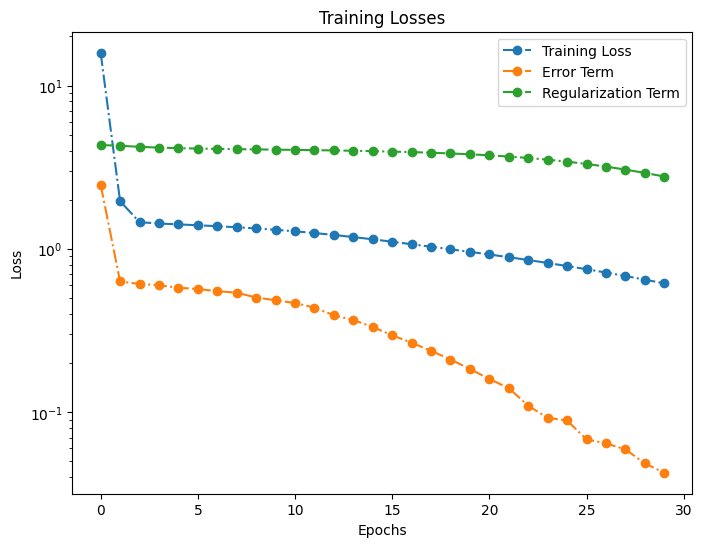

In [49]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='Training Loss')
plt.plot(range(len(history['error_term'])), history['error_term'], linestyle="-.", marker='o', label='Error Term')
plt.plot(range(len(history['reg_term'])), history['reg_term'], linestyle="-.", marker='o', label='Regularization Term')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.savefig('training_loss.png', dpi=300)

**Evaluate**

In [ ]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True, norm=True)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True, norm=True)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=batch_size, shuffle=True, norm=True)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=batch_size, shuffle=True, norm=True)

In [ ]:
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)
        # Compute mean loss
        #loss = loss_func(tn, embedded)
        #total_loss += loss.item() * batch.shape[0]
        #total_samples += batch.shape[0]

    return np.concatenate(all_scores)#, total_loss / total_samples


In [50]:
# Run the evaluation on bkg and signals
bkg_score = evaluate_model(model, background, loss_func_logquadnorm, embedding, verbose=True)
a4l_score = evaluate_model(model, a4l, loss_func_logquadnorm, embedding, verbose=True)
lq_score = evaluate_model(model, lq, loss_func_logquadnorm, embedding, verbose=True)
htnu_score = evaluate_model(model, htnu, loss_func_logquadnorm, embedding, verbose=True)
htt_score  = evaluate_model(model, htt, loss_func_logquadnorm, embedding, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:08<00:00,  7.93it/s]


**Plot anomaly scores and ROC curve**

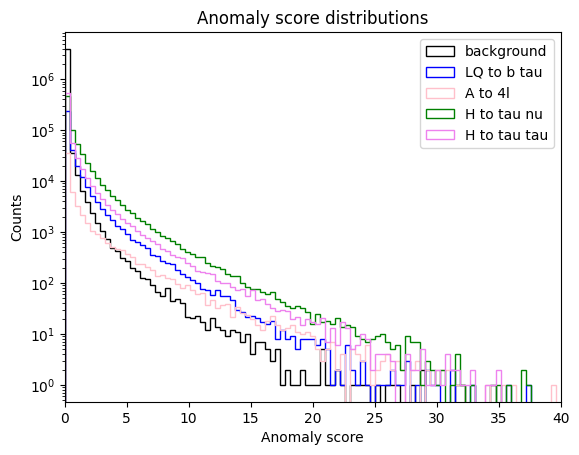

In [62]:
plt.figure()
plt.yscale('log')
xmax = 40
bins = np.linspace(0, xmax, 100)
plt.hist(bkg_score, bins=bins, histtype='step', color='black', label='background')
plt.hist(lq_score, bins=bins, histtype='step', color='blue', label='LQ to b tau')
plt.hist(a4l_score, bins=bins, histtype='step', color='pink', label='A to 4l')
plt.hist(htnu_score, bins=bins, histtype='step', color='green', label='H to tau nu')
plt.hist(htt_score, bins=bins, histtype='step', color='violet', label='H to tau tau')
plt.title('Anomaly score distributions')
plt.xlim([0, xmax])
plt.xlabel('Anomaly score')
plt.ylabel('Counts')
plt.legend()
plt.legend()
plt.savefig('anomaly_scores.png', dpi=300)

In [53]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 16.702862838297353


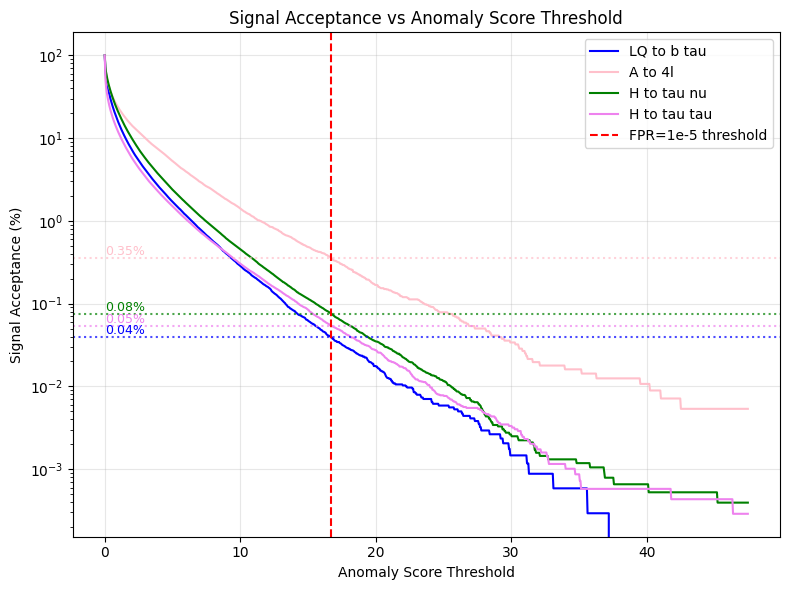

In [65]:
# Compute acceptance curves for each signal as a function of anomaly score threshold
thresholds = np.linspace(np.min(bkg_score), np.max(bkg_score), 1000)

def acceptance_curve(scores, thresholds):
   return np.array([(scores >= t).mean() for t in thresholds])

accept_lq = acceptance_curve(lq_score, thresholds)
accept_a4l = acceptance_curve(a4l_score, thresholds)
accept_htt = acceptance_curve(htt_score, thresholds)
accept_htnu = acceptance_curve(htnu_score, thresholds)

plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(thresholds, accept_lq * 100, color="blue", label="LQ to b tau")
plt.plot(thresholds, accept_a4l * 100, color="pink", label="A to 4l")
plt.plot(thresholds, accept_htnu * 100, color="green", label="H to tau nu")
plt.plot(thresholds, accept_htt * 100, color="violet", label="H to tau tau")
# Add horizontal lines and text for acceptance at score_threshold for each signal
for accept, label, color in [
   (accept_lq, "LQ to b tau", "blue"),
   (accept_a4l, "A to 4l", "pink"),
   (accept_htnu, "H to tau nu", "green"),
   (accept_htt, "H to tau tau", "violet"),
]:
   idx = np.searchsorted(thresholds, score_threshold, side="left")
   if idx >= len(accept):
      idx = -1
   acc_val = accept[idx] * 100
   plt.axhline(y=acc_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(thresholds[0], acc_val, f"{acc_val:.2f}%", color=color, va="bottom", fontsize=9)
plt.axvline(score_threshold, color='red', linestyle='--', label='FPR=1e-5 threshold')
plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Signal Acceptance (%)")
plt.title("Signal Acceptance vs Anomaly Score Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('signal_acceptance.png', dpi=300)

In [55]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

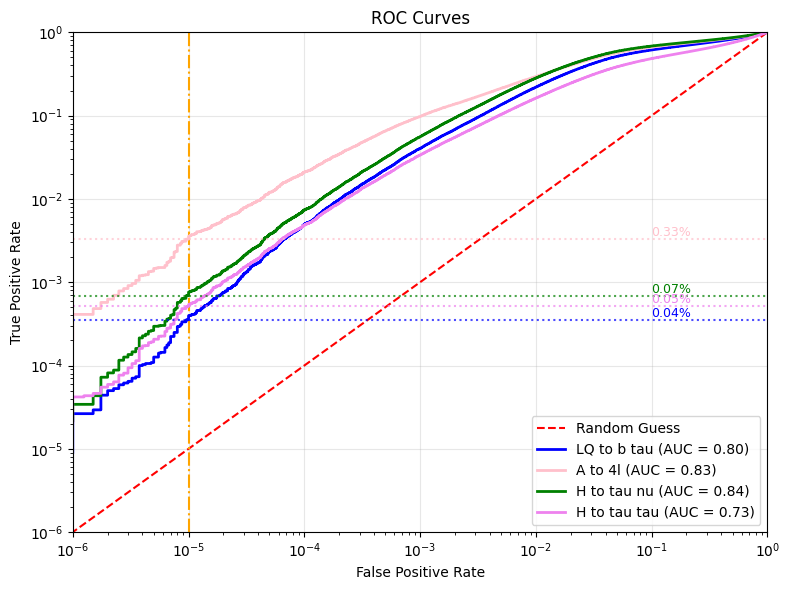

In [64]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="left")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)